# Demand and Supply Analysis for Ride-Sharing Services

We analyze the data about **ride demand** and **driver supply** in different based on each rides conditions.

In this dataset:

- `Number_of_Riders` = demand
- `Number_of_Drivers` = supply

The goal of this analysis is to understand the relationship between supply and demand, where surge conditions might appear - so we can improve the available offer, and which situations are the most critical ones. This feeds into two pricing questions:

1. Should pricing differ by **customer loyalty status and time of booking**?
2. How should pricing respond to real-time **supply-demand imbalance**?

## 1. Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load the cleaned data



In [2]:
df = pd.read_csv("cleaned_dynamic_pricing_with_features.csv")

df.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Demand_Supply_Ratio,Demand_Supply_Difference,Cost_per_Minute,Possible_Surge_Condition
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273,2.000000,45,3.158414,False
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753,1.487179,19,4.043599,False
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469,1.354839,11,4.339414,False
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232,3.178571,61,3.508964,False
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422,3.545455,56,3.890479,False


## 3. Quick data check

The data is already cleaned, but it is still useful to look at the structure before starting the analysis.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Number_of_Riders          1000 non-null   int64  
 1   Number_of_Drivers         1000 non-null   int64  
 2   Location_Category         1000 non-null   str    
 3   Customer_Loyalty_Status   1000 non-null   str    
 4   Number_of_Past_Rides      1000 non-null   int64  
 5   Average_Ratings           1000 non-null   float64
 6   Time_of_Booking           1000 non-null   str    
 7   Vehicle_Type              1000 non-null   str    
 8   Expected_Ride_Duration    1000 non-null   int64  
 9   Historical_Cost_of_Ride   1000 non-null   float64
 10  Demand_Supply_Ratio       1000 non-null   float64
 11  Demand_Supply_Difference  1000 non-null   int64  
 12  Cost_per_Minute           1000 non-null   float64
 13  Possible_Surge_Condition  1000 non-null   bool   
dtypes: bool(1), float64(

In [4]:
#overview of the conditions is which we are going to analyse the supply and demand
print("Location categories:", df["Location_Category"].unique())
print("Customer loyalty statuses:", df["Customer_Loyalty_Status"].unique())
print("Times of booking:", df["Time_of_Booking"].unique())
print("Vehicle types:", df["Vehicle_Type"].unique())

Location categories: <StringArray>
['Urban', 'Suburban', 'Rural']
Length: 3, dtype: str
Customer loyalty statuses: <StringArray>
['Silver', 'Regular', 'Gold']
Length: 3, dtype: str
Times of booking: <StringArray>
['Night', 'Evening', 'Afternoon', 'Morning']
Length: 4, dtype: str
Vehicle types: <StringArray>
['Premium', 'Economy']
Length: 2, dtype: str


## 4. Create demand and supply metrics

To analyze demand and supply, we previously created two new columns:

1. `Demand_Supply_Difference` = riders minus drivers
2. `Demand_Supply_Ratio` = riders divided by drivers

Interpretation:

- Difference greater than 0 means demand is higher than supply.
- Difference less than 0 means supply is higher than demand.
- Ratio greater than 1 means there are more riders than drivers.
- Ratio less than 1 means there are more drivers than riders.

In [5]:
df[["Number_of_Riders", "Number_of_Drivers", "Demand_Supply_Difference", "Demand_Supply_Ratio"]].head()

,Number_of_Riders,Number_of_Drivers,Demand_Supply_Difference,Demand_Supply_Ratio
0,90,45,45,2.000000
1,58,39,19,1.487179
2,42,31,11,1.354839
3,89,28,61,3.178571
4,78,22,56,3.545455


## 5. Overall demand and supply

This gives a general picture of whether the market has more riders or more drivers on average.

In [6]:
overall_demand_supply = df[["Number_of_Riders", "Number_of_Drivers"]].mean()

overall_demand_supply

Number_of_Riders     60.372
Number_of_Drivers    27.076
dtype: float64

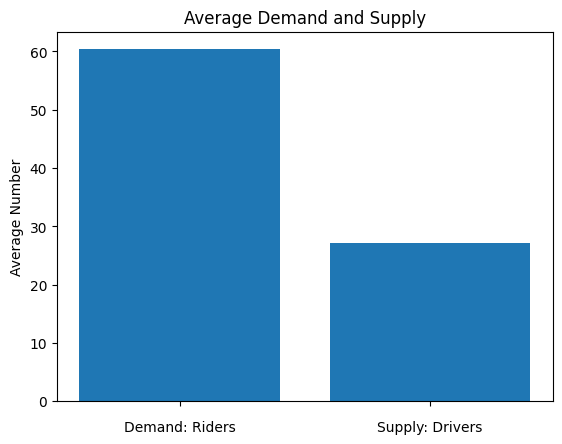

In [7]:
plt.bar(["Demand: Riders", "Supply: Drivers"], overall_demand_supply.values)

plt.title("Average Demand and Supply")
plt.ylabel("Average Number")
plt.tick_params(axis="x", pad=10)
plt.show()

## 6. Demand versus Supply

Is higher rider demand usually matched by enough driver supply?

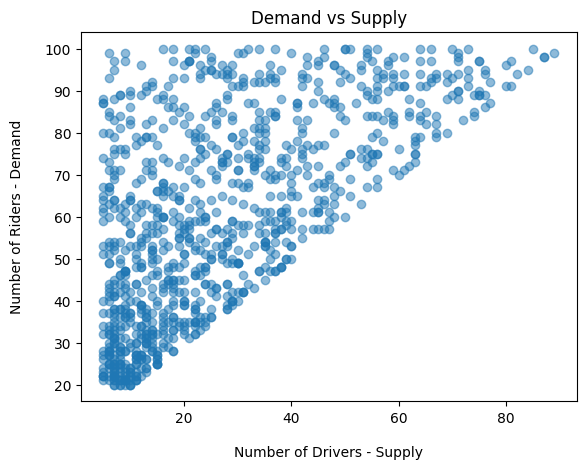

In [8]:
plt.scatter(df["Number_of_Drivers"], df["Number_of_Riders"], alpha=0.5)

plt.xlabel("Number of Drivers - Supply", labelpad=15)
plt.ylabel("Number of Riders - Demand", labelpad=15)
plt.title("Demand vs Supply")
plt.show()

When the number of riders increases, the number of drivers also often increases. 
However, many points have more riders than drivers, meaning that demand often exceeds supply. This suggests possible driver shortages, especially when rider numbers are high but driver availability is low.

## 7. Create demand pressure levels

We split the demand-supply ratio into three groups in order to be able to analyse different metrics based on this levels, and to inspect how the level of the demand and supply ratio behaves under different conditions (location, time):

- Low demand pressure
- Medium demand pressure
- High demand pressure

The `qcut()` function creates groups with approximately the same number of observations.

In [9]:
df["Demand_Supply_Level"] = pd.qcut(
    df["Demand_Supply_Ratio"],
    3,
    labels=["Low", "Medium", "High"]
)

df[["Demand_Supply_Ratio", "Demand_Supply_Level"]].head()

,Demand_Supply_Ratio,Demand_Supply_Level
0,2.000000,Medium
1,1.487179,Low
2,1.354839,Low
3,3.178571,High
4,3.545455,High


In [10]:
# quick  check if qcut gives roughly equal-sized groups
df["Demand_Supply_Level"].value_counts()

Demand_Supply_Level
Low       334
Medium    333
High      333
Name: count, dtype: int64

## 8. Summary by demand pressure level

This table shows how riders, drivers, the demand-supply gap, and the ratio change from low to high pressure conditions.

In [11]:
pressure_summary = df.groupby("Demand_Supply_Level", observed=False)[
    ["Number_of_Riders", "Number_of_Drivers", "Demand_Supply_Difference", "Demand_Supply_Ratio"]
].mean()

pressure_summary = pressure_summary.reindex(["Low", "Medium", "High"])

pressure_summary.round(2)

,Number_of_Riders,Number_of_Drivers,Demand_Supply_Difference,Demand_Supply_Ratio
Demand_Supply_Level,,,,
Low,66.12,45.98,20.14,1.49
Medium,54.68,23.24,31.44,2.41
High,60.29,11.95,48.35,5.81


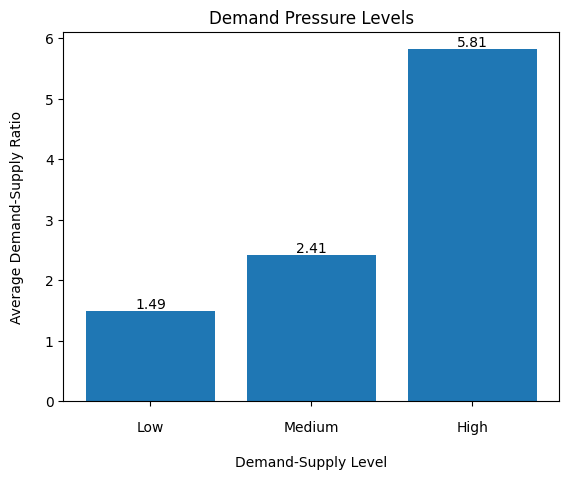

In [12]:
plt.bar(pressure_summary.index, pressure_summary["Demand_Supply_Ratio"])

plt.xlabel("Demand-Supply Level", labelpad=15)
plt.ylabel("Average Demand-Supply Ratio", labelpad=15)
plt.title("Demand Pressure Levels")
plt.tick_params(axis="x", pad=10)

for i, value in enumerate(pressure_summary["Demand_Supply_Ratio"]):
    plt.text(i, value, round(value, 2), ha="center", va="bottom")

plt.show()

## 9. Demand and supply by location

Which location type has the highest demand pressure?

In [13]:
location_order = ["Rural", "Suburban", "Urban"]

location_summary = df.groupby("Location_Category")[
    ["Number_of_Riders", "Number_of_Drivers", "Demand_Supply_Difference", "Demand_Supply_Ratio"]
].mean()

location_summary = location_summary.reindex(location_order)

location_summary.round(2)

,Number_of_Riders,Number_of_Drivers,Demand_Supply_Difference,Demand_Supply_Ratio
Location_Category,,,,
Rural,57.96,24.85,33.11,3.51
Suburban,62.29,28.51,33.78,3.13
Urban,60.91,27.88,33.03,3.07


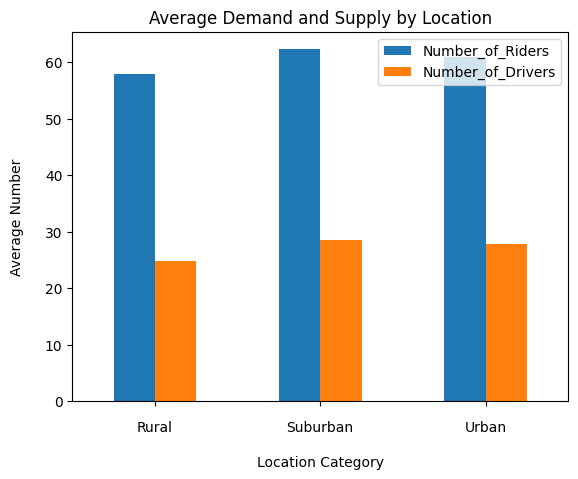

In [14]:
location_summary[["Number_of_Riders", "Number_of_Drivers"]].plot(kind="bar")

plt.xlabel("Location Category", labelpad=15)
plt.ylabel("Average Number", labelpad=15)
plt.title("Average Demand and Supply by Location")
plt.tick_params(axis="x", pad=10)
plt.xticks(rotation=0)
plt.show()

It shows that demand is higher than supply in all location categories. Suburban and urban areas have slightly higher average rider demand, but rural areas have the lowest driver availability.

In [15]:

#  location with the highest pressure 
highest_pressure_location = location_summary["Demand_Supply_Ratio"].idxmax()
print(f"Highest demand pressure location: {highest_pressure_location} "
      f"(ratio = {location_summary['Demand_Supply_Ratio'].max():.2f})")

Highest demand pressure location: Rural (ratio = 3.51)


## 10. Demand and supply by time of booking

At what time of day is demand pressure strongest?

In [16]:
time_order = ["Morning", "Afternoon", "Evening", "Night"]

time_summary = df.groupby("Time_of_Booking")[
    ["Number_of_Riders", "Number_of_Drivers", "Demand_Supply_Difference", "Demand_Supply_Ratio"]
].mean()

time_summary = time_summary.reindex(time_order)

time_summary.round(2)

,Number_of_Riders,Number_of_Drivers,Demand_Supply_Difference,Demand_Supply_Ratio
Time_of_Booking,,,,
Morning,59.65,26.17,33.48,3.19
Afternoon,59.55,27.45,32.09,3.12
Evening,60.52,27.48,33.03,3.19
Night,61.63,27.20,34.42,3.42


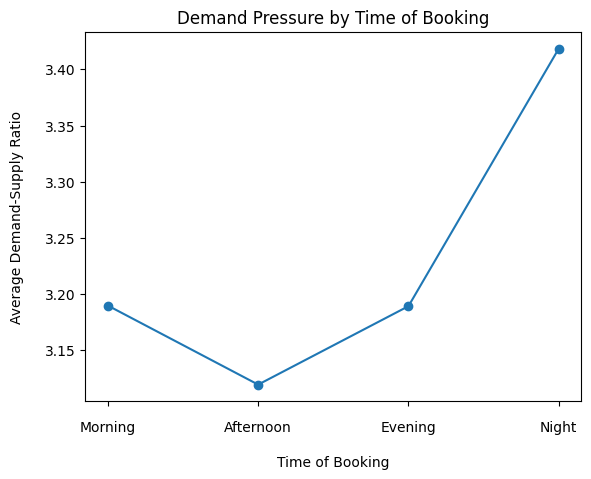

In [17]:
plt.plot(time_summary.index, time_summary["Demand_Supply_Ratio"], marker="o")

plt.xlabel("Time of Booking", labelpad=15)
plt.ylabel("Average Demand-Supply Ratio", labelpad=15)
plt.title("Demand Pressure by Time of Booking")
plt.tick_params(axis="x", pad=10)
plt.show()

The line chart shows that the demand-supply ratio spikes during the night, since there are much fewer drivers available compared to the number of rides requested. We can observe that demand pressure is at its highest in the night, and at its lowest in the afternoon, meaning there is a bigger ratio of rides needed vs. drivers available in the night.

## 11. Location and time together

**Where and when** demand pressure is highest at the same time?

In [18]:
heatmap_data = pd.pivot_table(
    df,
    values="Demand_Supply_Ratio",
    index="Location_Category",
    columns="Time_of_Booking",
    aggfunc="mean"
)

heatmap_data = heatmap_data.reindex(
    index=["Rural", "Suburban", "Urban"],
    columns=["Morning", "Afternoon", "Evening", "Night"]
)

heatmap_data.round(2)

Time_of_Booking,Morning,Afternoon,Evening,Night
Location_Category,,,,
Rural,3.08,3.16,3.77,4.01
Suburban,3.38,3.08,2.90,3.13
Urban,3.09,3.12,2.83,3.18


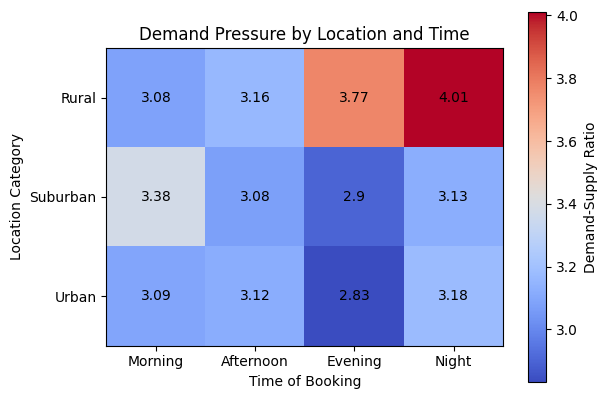

In [19]:
plt.imshow(heatmap_data, cmap="coolwarm")

plt.colorbar(label="Demand-Supply Ratio")
plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

plt.xlabel("Time of Booking")
plt.ylabel("Location Category")
plt.title("Demand Pressure by Location and Time")

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        plt.text(j, i, round(value, 2), ha="center", va="center")

plt.show()

The highest demand-supply ratio appears in rural areas at night, followed by rural areas in the evening. This suggests that rural locations experience the strongest driver shortage, especially later in the day. In contrast, urban evening rides show the lowest demand pressure.

## 12. Top demand pressure situations

When and where are the top 5 potential surge situations based on location and time?

In [20]:
surge_candidates = df.groupby(["Location_Category", "Time_of_Booking"])[
    "Demand_Supply_Ratio"
].mean().reset_index()

surge_candidates = surge_candidates.sort_values("Demand_Supply_Ratio", ascending=False)

surge_candidates.head(10).round(2)

,Location_Category,Time_of_Booking,Demand_Supply_Ratio
3,Rural,Night,4.01
1,Rural,Evening,3.77
6,Suburban,Morning,3.38
11,Urban,Night,3.18
0,Rural,Afternoon,3.16
7,Suburban,Night,3.13
8,Urban,Afternoon,3.12
10,Urban,Morning,3.09
2,Rural,Morning,3.08
4,Suburban,Afternoon,3.08


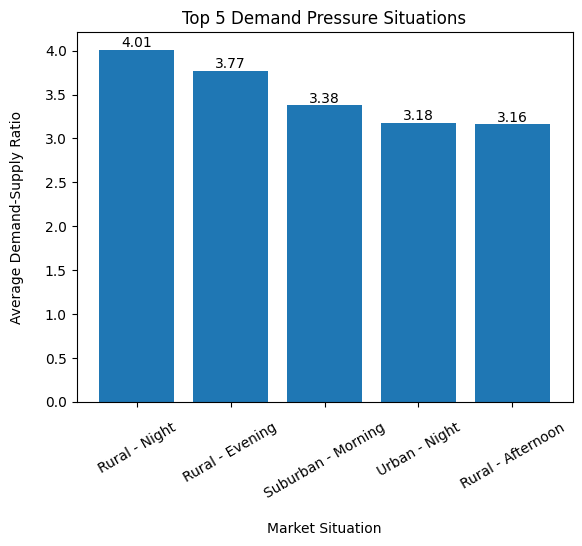

In [21]:
top_surge = surge_candidates.head(5).copy()
top_surge["Market_Situation"] = top_surge["Location_Category"] + " - " + top_surge["Time_of_Booking"]

plt.bar(top_surge["Market_Situation"], top_surge["Demand_Supply_Ratio"])

plt.xlabel("Market Situation", labelpad=15)
plt.ylabel("Average Demand-Supply Ratio", labelpad=15)
plt.title("Top 5 Demand Pressure Situations")
plt.tick_params(axis="x", pad=10)
plt.xticks(rotation=30)

for i, value in enumerate(top_surge["Demand_Supply_Ratio"]):
    plt.text(i, value, round(value, 2), ha="center", va="bottom")

plt.show()

I'd expect loyalty status to matter less for the actual supply-demand balance than location or time do, since loyalty is a customer attribute rather than a market condition — but it's worth checking directly.

## 13. Demand pressure by customer loyalty status

In [22]:
loyalty_order = ["Regular", "Silver", "Gold"]

loyalty_summary = df.groupby("Customer_Loyalty_Status")[
    ["Number_of_Riders", "Number_of_Drivers", "Demand_Supply_Difference", "Demand_Supply_Ratio"]
].mean()

loyalty_summary = loyalty_summary.reindex(loyalty_order)

loyalty_summary.round(2)

,Number_of_Riders,Number_of_Drivers,Demand_Supply_Difference,Demand_Supply_Ratio
Customer_Loyalty_Status,,,,
Regular,62.75,29.81,32.94,2.92
Silver,59.40,25.62,33.78,3.32
Gold,59.09,25.99,33.09,3.47


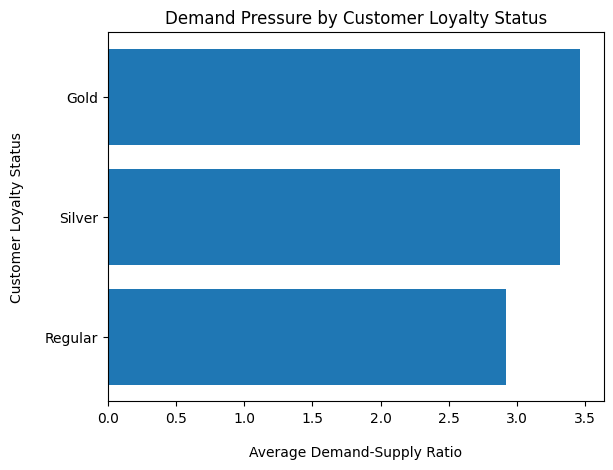

In [23]:
plt.barh(loyalty_summary.index, loyalty_summary["Demand_Supply_Ratio"])

plt.xlabel("Average Demand-Supply Ratio", labelpad=15)
plt.ylabel("Customer Loyalty Status", labelpad=15)
plt.title("Demand Pressure by Customer Loyalty Status")
plt.show()

Demand pressure differs by customer loyalty status. Gold customers show the highest average demand-supply ratio, followed by Silver and Regular customers. This suggests that higher-loyalty customers are more often associated with market situations where demand is high compared to driver availability. However, this does not necessarily mean that loyal customers cause the shortage; it only shows an observed relationship in the dataset.

## 14. Demand and supply by vehicle type

This section asks: **is demand pressure different for Economy and Premium rides?**

In [24]:
vehicle_order = ["Economy", "Premium"]

vehicle_summary = df.groupby("Vehicle_Type")[
    ["Number_of_Riders", "Number_of_Drivers", "Demand_Supply_Difference", "Demand_Supply_Ratio"]
].mean()

vehicle_summary = vehicle_summary.reindex(vehicle_order)

vehicle_summary.round(2)

,Number_of_Riders,Number_of_Drivers,Demand_Supply_Difference,Demand_Supply_Ratio
Vehicle_Type,,,,
Economy,60.44,26.78,33.66,3.39
Premium,60.31,27.35,32.97,3.10


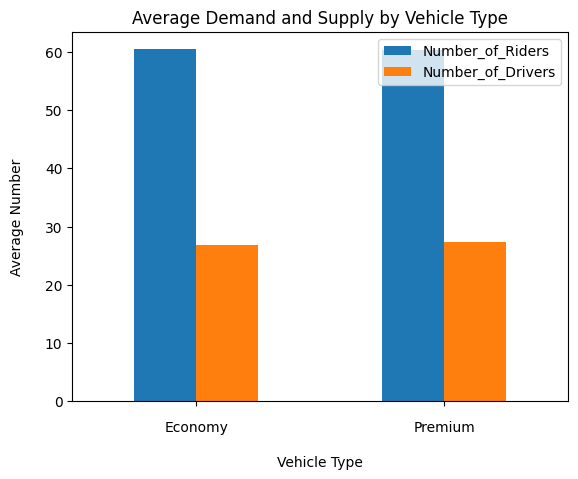

In [25]:
vehicle_summary[["Number_of_Riders", "Number_of_Drivers"]].plot(kind="bar")

plt.xlabel("Vehicle Type", labelpad=15)
plt.ylabel("Average Number", labelpad=15)
plt.title("Average Demand and Supply by Vehicle Type")
plt.tick_params(axis="x", pad=10)
plt.xticks(rotation=0)
plt.show()

In [26]:

for vehicle, ratio in vehicle_summary["Demand_Supply_Ratio"].items():
    print(f"{vehicle}: average demand-supply ratio = {ratio:.2f}")

Economy: average demand-supply ratio = 3.39
Premium: average demand-supply ratio = 3.10


## 15. Findings and business recommendations

The overall average demand-supply ratio across the dataset is 3.24 (about 3.24 riders for every driver). The most important finding is that this imbalance is heavily concentrated in specific location-time combinations rather than spread evenly:

- **Rural areas at night are the single worst imbalance in the dataset:** ratio of 4.01, about 24% above the overall average, and the highest of all 12 location-time combinations (Section 11). Rural evening is close behind at 3.77. Urban evening is the opposite extreme, at 2.83 — about 13% below average and the lowest combination overall.
- **Time of day matters more consistently than location alone:** night has the highest average ratio (3.42), afternoon the lowest (3.12), a gap that holds regardless of location (Section 10).
- **Loyalty status correlates with pressure, but the pattern doesn't imply causation:** Gold customers show the highest average ratio (3.47), followed by Silver (3.32), then Regular (2.92) — but this only means loyal customers happen to book more often during high-pressure moments, not that they cause the shortage (Section 13).
- **Vehicle type shows a smaller but real gap:** Economy rides average a 3.39 ratio versus 3.10 for Premium (Section 14).

**What this means for pricing:**

- Surge pricing should scale with time of day first, since that's the most consistent driver of imbalance — highest multipliers at night, lowest in the afternoon.
- Within that, rural night and rural evening deserve extra attention (either surge pricing or targeted driver incentives), since they're the two most extreme situations in the whole dataset, well above the average.
- Loyalty status should not be used to justify higher fares, since the data only shows correlation, not cause — instead, loyalty can be used to layer rewards or discounts on top of time-based surge pricing, without undermining the loyalty program.
- Given Economy rides run a higher average ratio than Premium, driver incentive programs may have more impact if weighted toward increasing Economy driver availability during the identified high-pressure windows.

These findings and recommendations are based only on the demand-supply patterns observed in this dataset; they don't account for cost-side factors, which are covered separately in the team's cost analysis.